<a href="https://colab.research.google.com/github/qja0707/OralMedicineImageDetection/blob/docs%2Fgyubeom%2Fmerge_taejin/members/gyubeom/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

경구약제 객체 탐지 프로젝트 데이터 분석용 노트북

## 파일 분석

In [1]:
import kagglehub
import os

# 임시 팀 공유용 Kaggle API 토큰
# 프로젝트 종료 후 반드시 폐기 예정
# 폐기 후에는 새 토큰을 각자 환경변수로 설정해서 사용
os.environ['KAGGLE_API_TOKEN'] = "KGAT_957ae188e2917ffae289bcff9a2733e5"

# Download latest version
path = kagglehub.competition_download('ai10-level1-project')

print("Path to competition files:", path)

100%|██████████| 1.79G/1.79G [01:38<00:00, 19.5MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/ai10-level1-project


In [2]:
path = os.path.join(path, 'sprint_ai_project1_data')
print(os.listdir(path))

['test_images', 'train_annotations', 'train_images']


In [3]:
test_images_path = os.path.join(path, 'test_images')

train_images_path = os.path.join(path, 'train_images')

train_annotations_path = os.path.join(path, 'train_annotations')


### 이미지 파일 이름 체크

In [4]:
import re

count = 0

for root, dirs, files in os.walk(train_images_path):
    for file in files:
        count +=1
        # 확장자 제외한 파일명만 추출
        name = os.path.splitext(file)[0]

        name = name.split("_")[0]

        print(name)

        if count > 10:
            break

K-001900-016548-019607-033009
K-003351-016688-041768
K-003351-003832-021325
K-003351-018147-035206
K-002483-012081-012778-025438
K-003351-019232-029667
K-003351-019232-021325
K-003351-013900-036637
K-003351-020014-021325
K-003351-033880-035206
K-003351-016232-019232


이미지 데이터에 포함되어있는 알약 코드의 나열로 파일 이름이 정해져있음

### COCO JSON 파일 병합

coco json 파일은 같은 이미지마다 찍는 조건(rotation 각도)에 따라 분할되어있으므로 이를 하나의 json 파일로 병합

In [5]:
import json
from pathlib import Path
from collections import defaultdict
import glob
import os

OUTPUT_DIR = './eda_output'

if OUTPUT_DIR:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

train_jsons = glob.glob(train_annotations_path+'/**/*.json', recursive=True)

train_pngs = os.listdir(train_images_path)



print(f"  발견한 train JSON : {len(train_jsons)}개")
print(f"  발견한 train PNG  : {len(train_pngs)}개")



# 카테고리 수집 및 순차적으로 ID 부여 후 매핑
print("\n" + "=" * 55)
print("2단계: 카테고리 수집 & ID 매핑 생성 중...")
print("=" * 55)

# 카테고리명 → dl_idx(원본 숫자 ID) 수집
#   JSON 구조: categories[0].name = 약품명, categories[0].id = dl_idx
name_to_dlid: dict[str, int] = {}   # 약품명 → 원본 dl_idx
dlid_to_name: dict[int, str] = {}   # 원본 dl_idx → 약품명

for jf in train_jsons:
    with open(jf, "r", encoding="utf-8") as f:
        data = json.load(f)

    for cat in data.get("categories", []):
        name = cat.get("name", "").strip()
        cid = cat.get("id")

        if name and cid is not None:
            name_to_dlid[name] = cid
            dlid_to_name[cid] = name



print(f"  고유 카테고리 수  : {len(name_to_dlid)}개")

# 매핑 테이블 저장
mapping = {
    "description": "category_name ↔ original category_id 매핑 테이블",
    "total_categories": len(name_to_dlid),
    "name_to_original_id": name_to_dlid,
    "original_id_to_name": {str(k): v for k, v in dlid_to_name.items()},
}

mapping_path = os.path.join(OUTPUT_DIR,"category_mapping.json")
with open(mapping_path, "w", encoding="utf-8") as f:
    json.dump(mapping, f, ensure_ascii=False, indent=2)
print(f"  매핑 테이블 저장  : {mapping_path}")



# 이미지 파일명 및 이미지 ID 매핑
print("\n" + "=" * 55)
print("3단계: 이미지 ID 매핑 생성 중...")
print("=" * 55)

# train_images 폴더 안의 PNG 파일명으로 image_id 결정
# 파일명 예: K-001900-016548-019607-029451_0_2_0_2_70_000_200.png
# image_id = 파일명의 숫자 부분 (파일명 자체를 hash 또는 순번으로)

filename_to_imageid: dict[str, int] = {}
imageid_to_filename: dict[int, str] = {}

for idx, png_path in enumerate(sorted(train_pngs), start=1):
    fname = Path(png_path).name   # 예: K-001900-..._200.png
    filename_to_imageid[fname] = idx
    imageid_to_filename[idx]   = fname

print(f"  총 이미지 수      : {len(filename_to_imageid)}개")



#전체 JSON 파싱 → COCO 통합 구조
print("\n" + "=" * 55)
print("4단계: JSON 763개 파싱 & COCO 통합 JSON 조립 중...")
print("=" * 55)

coco_annotations: list[dict] = []
annotation_metadata: list[dict] = []

seen_image_ids:  set[int] = set()
annotation_id_counter = 1
skip_count   = 0
bbox_invalid = 0
meta_missing = 0
meta_duplicate = 0

# 이미 수집한 image 정보를 JSON에서도 읽어둠
image_id_info: dict[int, dict] = {}

image_level_keys = [
    "file_name", "width", "height", "back_color", "light_color",
    "camera_la", "camera_lo", "size", "img_regist_ts"
]

annotation_meta_keys = [
    "drug_N", "drug_S", "drug_dir", "dl_idx", "dl_mapping_code", "dl_name", "dl_name_en",
    "img_key", "dl_material", "dl_material_en", "dl_custom_shape", "dl_company", "dl_company_en",
    "di_company_mf", "di_company_mf_en", "item_seq", "di_item_permit_date", "di_class_no",
    "di_etc_otc_code", "di_edi_code", "chart", "drug_shape", "thick", "leng_long", "leng_short",
    "print_front", "print_back", "color_class1", "color_class2", "line_front", "line_back",
    "form_code_name", "mark_code_front_anal", "mark_code_back_anal", "mark_code_front_img",
    "mark_code_back_img", "mark_code_front", "mark_code_back", "change_date"
]

for jf in train_jsons:
        with open(jf, "r", encoding="utf-8") as f:
            data = json.load(f)

        # 이미지 정보
        images_in_json = data.get("images", [])
        if not images_in_json:
            skip_count += 1
            continue

        img_info  = images_in_json[0]
        file_name = img_info.get("file_name", "")

        # image_id 결정: 파일명으로 찾거나 없으면 신규 부여
        fname_only = Path(file_name).name
        if fname_only in filename_to_imageid:
            image_id = filename_to_imageid[fname_only]
        else:
            # 파일명이 다를 경우 순번으로 처리
            image_id = len(filename_to_imageid) + len(seen_image_ids) + 1
            filename_to_imageid[fname_only] = image_id

        # 이미지 중복 등록 방지
        if image_id not in seen_image_ids:
            seen_image_ids.add(image_id)
            image_id_info[image_id] = {
                "id"       : image_id,
                "file_name": fname_only,
                "width"    : img_info.get("width", 0),
                "height"   : img_info.get("height", 0),
                "imgfile"  : img_info.get("imgfile", fname_only),
                "back_color": img_info.get("back_color", ""),
                "light_color": img_info.get("light_color", ""),
                "camera_la": img_info.get("camera_la"),
                "camera_lo": img_info.get("camera_lo"),
                "size": img_info.get("size"),
                "img_regist_ts": img_info.get("img_regist_ts", ""),
            }

        annotation_meta_map: dict[int, list[dict]] = defaultdict(list)
        for raw_meta in images_in_json:
            raw_dlid = raw_meta.get("dl_idx")
            try:
                meta_category_id = int(raw_dlid)
            except (TypeError, ValueError):
                continue
            annotation_meta_map[meta_category_id].append(raw_meta)

        # 어노테이션
        for ann in data.get("annotations", []):
            bbox = ann.get("bbox")
            cat_id = ann.get("category_id")
            area = ann.get("area")
            iscrowd = ann.get("iscrowd", 0)
            segmentation = ann.get("segmentation", [])
            ignore = ann.get("ignore",0)

            # 유효성 검사: bbox 존재 & 길이 4
            if not isinstance(bbox, list) or len(bbox) != 4:
                print(f"isinstance: {isinstance(bbox, list)}")
                print(f"len(bbox): {len(bbox)}")

                bbox_invalid += 1
                continue

            # bbox 값이 모두 0인 경우 제외 (빈 bbox)
            if all(v == 0 for v in bbox):
                bbox_invalid += 1
                continue

            coco_annotations.append({
                "id"         : annotation_id_counter,
                "image_id"   : image_id,
                "category_id": cat_id,
                "bbox"       : bbox,
                "area"       : area,
                "iscrowd"    : iscrowd,
                "segmentation": segmentation,
                "ignore":ignore,
            })

            matched_meta = None
            candidates = annotation_meta_map.get(cat_id, [])
            if candidates:
                matched_meta = candidates.pop(0)
                if candidates:
                    meta_duplicate += len(candidates)
            else:
                meta_missing += 1

            meta_record = {
                "annotation_id": annotation_id_counter,
                "image_id": image_id,
                "category_id": cat_id,
                "file_name": fname_only,
            }

            for key in image_level_keys:
                meta_record[key] = img_info.get(key)

            for key in annotation_meta_keys:
                meta_record[key] = matched_meta.get(key) if matched_meta else None

            annotation_metadata.append(meta_record)
            annotation_id_counter += 1

# 이미지 리스트 정렬
coco_images = sorted(image_id_info.values(), key=lambda x: x["id"])

print(f"  처리된 이미지 수  : {len(coco_images)}개")
print(f"  유효 어노테이션   : {len(coco_annotations)}개")
print(f"  무효/스킵 수      : {skip_count + bbox_invalid}개")
print(f"  메타 누락 수      : {meta_missing}개")
print(f"  메타 중복 후보 수 : {meta_duplicate}개")



# 5단계: COCO categories 리스트 생성
coco_categories = [
    {
        "id": original_id,
        "name": name,
        "supercategory": "pill",
    }
    for original_id, name in sorted(dlid_to_name.items(), key=lambda x: x[0])
]



# 6단계: 통합 COCO JSON 저장
print("\n" + "=" * 55)
print("5단계: 통합 COCO JSON 저장 중...")
print("=" * 55)

coco_output = {
    "info": {
        "description": "알약 탐지 프로젝트 통합 어노테이션",
        "version"    : "1.0",
        "total_images"     : len(coco_images),
        "total_annotations": len(coco_annotations),
        "total_categories" : len(coco_categories),
    },
    "images"     : coco_images,
    "annotations": coco_annotations,
    "categories" : coco_categories,
}

train_coco_path = os.path.join(OUTPUT_DIR, "train_coco.json")
with open(train_coco_path, "w", encoding="utf-8") as f:
    json.dump(coco_output, f, ensure_ascii=False, indent=2)
print(f"  저장 완료         : {train_coco_path}")

annotation_metadata_path = os.path.join(OUTPUT_DIR, "annotation_metadata.json")
with open(annotation_metadata_path, "w", encoding="utf-8") as f:
    json.dump(annotation_metadata, f, ensure_ascii=False, indent=2)
print(f"  메타 저장 완료    : {annotation_metadata_path}")



# 7단계: 데이터 현황 요약 리포트
print("\n" + "=" * 55)
print("6단계: 데이터 현황 리포트 생성 중...")
print("=" * 55)

# 클래스별 어노테이션 수 집계
class_ann_count: dict[int, int] = defaultdict(int)
for ann in coco_annotations:
    class_ann_count[ann["category_id"]] += 1

# 이미지당 알약 수 집계
img_pill_count: dict[int, int] = defaultdict(int)
for ann in coco_annotations:
    img_pill_count[ann["image_id"]] += 1

pill_counts   = list(img_pill_count.values())
avg_per_image = sum(pill_counts) / len(pill_counts) if pill_counts else 0
dist          = defaultdict(int)
for c in pill_counts:
    dist[c] += 1

report_lines = [
    "=" * 55,
    "  알약 탐지 데이터셋 현황 요약",
    "=" * 55,
    f"  Train 이미지 수        : {len(coco_images)}장",
    f"  Train 어노테이션 수    : {len(coco_annotations)}개",
    f"  카테고리(약품) 수      : {len(coco_categories)}종",
    f"  이미지당 평균 알약 수  : {avg_per_image:.2f}개",
    f"  메타 누락 수           : {meta_missing}개",
    f"  메타 중복 후보 수      : {meta_duplicate}개",
    "",
    "  이미지당 알약 수 분포",
    *[f"    알약 {k}개짜리 이미지  : {v}장" for k, v in sorted(dist.items())],
    "",
    "  클래스별 어노테이션 수 (적은 순)",
    *[
    f"    [{cat_id:>6}] {dlid_to_name.get(cat_id, 'UNKNOWN'):<35} : {class_ann_count[cat_id]}개"
    for cat_id in sorted(class_ann_count, key=lambda x: class_ann_count[x])
    ],
    "",
    f"  최소 클래스 어노테이션 : {min(class_ann_count.values())}개",
    f"  최대 클래스 어노테이션 : {max(class_ann_count.values())}개",
    f"  평균 클래스 어노테이션 : {sum(class_ann_count.values())/len(class_ann_count):.1f}개",
    "=" * 55,
]

report_text = "\n".join(report_lines)
print(report_text)

summary_path = os.path.join(OUTPUT_DIR, "dataset_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(report_text)
print(f"\n  리포트 저장       : {summary_path}")

print("\n" + "=" * 55)
print("  완료! 생성된 파일 목록")
print("=" * 55)
print(f"  1. {train_coco_path}")
print(f"  2. {annotation_metadata_path}")
print(f"  3. {mapping_path}")
print(f"  4. {summary_path}")
print("=" * 55)


  발견한 train JSON : 763개
  발견한 train PNG  : 232개

2단계: 카테고리 수집 & ID 매핑 생성 중...
  고유 카테고리 수  : 56개
  매핑 테이블 저장  : ./eda_output/category_mapping.json

3단계: 이미지 ID 매핑 생성 중...
  총 이미지 수      : 232개

4단계: JSON 763개 파싱 & COCO 통합 JSON 조립 중...
  처리된 이미지 수  : 232개
  유효 어노테이션   : 763개
  무효/스킵 수      : 0개
  메타 누락 수      : 0개
  메타 중복 후보 수 : 0개

5단계: 통합 COCO JSON 저장 중...
  저장 완료         : ./eda_output/train_coco.json
  메타 저장 완료    : ./eda_output/annotation_metadata.json

6단계: 데이터 현황 리포트 생성 중...
  알약 탐지 데이터셋 현황 요약
  Train 이미지 수        : 232장
  Train 어노테이션 수    : 763개
  카테고리(약품) 수      : 56종
  이미지당 평균 알약 수  : 3.29개
  메타 누락 수           : 0개
  메타 중복 후보 수      : 0개

  이미지당 알약 수 분포
    알약 2개짜리 이미지  : 7장
    알약 3개짜리 이미지  : 151장
    알약 4개짜리 이미지  : 74장

  클래스별 어노테이션 수 (적은 순)
    [ 27926] 울트라셋이알서방정                           : 3개
    [ 21771] 라비에트정 20mg                          : 3개
    [  3743] 알드린정                                : 3개
    [ 13395] 써스펜8시간이알서방정 650mg                   : 3개
    [ 27993] 졸로푸트정 10

### 이미지 확장자 / 해상도 / 크기 확인

In [6]:
import os
from PIL import Image
from collections import Counter

# 1. 초기화
extensions = Counter()     # 확장자별 개수
resolutions = Counter()    # 해상도(W, H)별 개수
file_sizes = []            # 파일 용량 리스트 (MB 단위)

# 2. 순회 및 분석
for root, dirs, files in os.walk(train_images_path):
    for file in files:
        if file.startswith('.'): continue

        file_path = os.path.join(root, file)

        # 1) 확장자 추출 및 카운트
        ext = os.path.splitext(file)[1].lower()
        extensions[ext] += 1

        # 2) 파일 크기 계산 (Byte -> MB)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        file_sizes.append(size_mb)

        # 3) 이미지 해상도 추출
        try:
            with Image.open(file_path) as img:
                resolutions[img.size] += 1
        except:
            # 이미지가 아니거나 손상된 파일인 경우
            pass

# 3. 통계 결과 출력
print(f"📊 [파일 기술 통계 분석]")
print("-" * 45)

# 확장자 분포
print(f"✅ 유니크 확장자:")
for ext, count in extensions.items():
    print(f" - {ext if ext else 'No Ext'}: {count}개")

# 해상도 분포 (상위 5개)
print(f"\n✅ 해상도 분포 (가로 x 세로):")
for res, count in resolutions.most_common(5):
    print(f" - {res[0]} x {res[1]}: {count}개")

# 용량 통계
total_size = sum(file_sizes)
avg_size = total_size / len(file_sizes) if file_sizes else 0
print(f"\n✅ 파일 용량 통계:")
print(f" - 전체 합계: {total_size:.2f} MB")
print(f" - 평균 용량: {avg_size:.2f} MB")
print(f" - 최대 용량: {max(file_sizes) if file_sizes else 0:.2f} MB")
print(f" - 최소 용량: {min(file_sizes) if file_sizes else 0:.2f} MB")
print("-" * 45)


📊 [파일 기술 통계 분석]
---------------------------------------------
✅ 유니크 확장자:
 - .png: 232개

✅ 해상도 분포 (가로 x 세로):
 - 976 x 1280: 232개

✅ 파일 용량 통계:
 - 전체 합계: 387.67 MB
 - 평균 용량: 1.67 MB
 - 최대 용량: 1.92 MB
 - 최소 용량: 1.50 MB
---------------------------------------------


## 이미지 데이터 분석

### 클래스별 분포 시각화

In [7]:
# 1. 나눔 폰트 설치
!apt-get -qy install fonts-nanum


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,886 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 시스템에 설치된 폰트 리스트 업데이트
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')

# 2. 전역 설정 (Malgun Gothic 대신 사용)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 3. 확인 (나눔바른고딕이 출력되어야 함)
print(plt.rcParams['font.family'])


['NanumBarunGothic']


In [9]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
from PIL import Image

def run_eda_from_coco(
    coco_json_path,
    train_images_path,
    dlid_to_name,
    output_dir,
    show_plot=True
):
    coco_json_path = Path(coco_json_path)
    train_images_path = Path(train_images_path)
    output_dir = Path(output_dir)

    eda_dir = output_dir
    eda_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 60)
    print("EDA 시작")
    print("=" * 60)

    with open(coco_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    images = coco["images"]
    annotations = coco["annotations"]
    categories = coco["categories"]

    print(f"이미지 수      : {len(images)}장")
    print(f"어노테이션 수  : {len(annotations)}개")
    print(f"카테고리 수    : {len(categories)}종")

    # -------------------------
    # 집계
    # -------------------------
    class_ann_count = defaultdict(int)
    for ann in annotations:
        class_ann_count[ann["category_id"]] += 1

    img_pill_count = defaultdict(int)
    for ann in annotations:
        img_pill_count[ann["image_id"]] += 1

    image_info_map = {img["id"]: img for img in images}

    img_anns = defaultdict(list)
    for ann in annotations:
        img_anns[ann["image_id"]].append(ann)

    bbox_areas = [ann["area"] for ann in annotations]
    bbox_widths = [ann["bbox"][2] for ann in annotations]
    bbox_heights = [ann["bbox"][3] for ann in annotations]
    bbox_aspect_ratios = [ann["bbox"][2] / ann["bbox"][3] for ann in annotations if ann["bbox"][3] != 0]

    img_widths = [img["width"] for img in images]
    img_heights = [img["height"] for img in images]

    # -------------------------
    # 1. 클래스별 분포
    # -------------------------
    print("\n[1] 클래스별 분포")

    sorted_classes = sorted(class_ann_count.items(), key=lambda x: x[1], reverse=True)
    names = [dlid_to_name.get(cid, str(cid))[:10] for cid, _ in sorted_classes]
    counts = [cnt for _, cnt in sorted_classes]

    fig, ax = plt.subplots(figsize=(18, 6))

    colors = [
        "#E24B4A" if c <= 5 else
        "#EF9F27" if c <= 12 else
        "#1D9E75"
        for c in counts
    ]

    bars = ax.bar(
        range(len(names)),
        counts,
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )

    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("약품명")
    ax.set_ylabel("어노테이션 수")
    ax.set_title("클래스별 어노테이션 수 분포")

    mean_count = np.mean(counts)
    ax.axhline(
        y=mean_count,
        color="gray",
        linestyle="--",
        alpha=0.7,
        label=f"평균 {mean_count:.1f}"
    )
    ax.legend()

    for bar, cnt in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(cnt),
            ha="center",
            va="bottom",
            fontsize=7
        )

    plt.tight_layout()
    plt.savefig(eda_dir / "01_class_distribution.png", dpi=150, bbox_inches="tight")
    if show_plot:
        plt.show()
    plt.close()

    # -------------------------
    # 2. 이미지당 알약 수
    # -------------------------
    print("[2] 이미지당 알약 수")

    pill_dist = defaultdict(int)
    for cnt in img_pill_count.values():
        pill_dist[cnt] += 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    labels = [f"{k}개\n({v}장)" for k, v in sorted(pill_dist.items())]
    sizes = [v for _, v in sorted(pill_dist.items())]

    palette = ["#85B7EB", "#1D9E75", "#EF9F27", "#E24B4A"]

    axes[0].pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=palette[:len(sizes)]
    )
    axes[0].set_title("이미지당 알약 수 분포")

    keys = sorted(pill_dist.keys())
    vals = [pill_dist[k] for k in keys]

    axes[1].bar(
        [f"{k}개" for k in keys],
        vals,
        color=palette[:len(vals)],
        edgecolor="white"
    )
    axes[1].set_title("이미지당 알약 수")
    axes[1].set_xlabel("알약 개수")
    axes[1].set_ylabel("이미지 수")

    for i, v in enumerate(vals):
        axes[1].text(i, v + 0.2, str(v), ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(eda_dir / "02_pills_per_image.png", dpi=150, bbox_inches="tight")
    if show_plot:
        plt.show()
    plt.close()

    # -------------------------
    # 3. bbox 크기 분포
    # -------------------------
    print("[3] bbox 크기 분포")

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].hist(bbox_widths, bins=30, edgecolor="white")
    axes[0].set_title("bbox 너비")
    axes[0].axvline(np.mean(bbox_widths), color="red", linestyle="--")

    axes[1].hist(bbox_heights, bins=30, edgecolor="white")
    axes[1].set_title("bbox 높이")
    axes[1].axvline(np.mean(bbox_heights), color="red", linestyle="--")

    axes[2].hist(bbox_areas, bins=30, edgecolor="white")
    axes[2].set_title("bbox 면적")
    axes[2].axvline(np.mean(bbox_areas), color="red", linestyle="--")

    axes[3].hist(bbox_aspect_ratios, bins=30, edgecolor="white")
    axes[3].set_title("bbox 종횡비")
    axes[3].axvline(np.mean(bbox_aspect_ratios), color="red", linestyle="--")

    plt.tight_layout()
    plt.savefig(eda_dir / "03_bbox_size_distribution.png", dpi=150, bbox_inches="tight")
    if show_plot:
        plt.show()
    plt.close()

    # -------------------------
    # 4. bbox 위치 히트맵
    # -------------------------
    print("[4] bbox 위치 히트맵")

    cx_list, cy_list = [], []

    for ann in annotations:
        img = image_info_map.get(ann["image_id"])
        if img is None:
            continue

        x, y, w, h = ann["bbox"]
        cx = (x + w / 2) / img["width"]
        cy = (y + h / 2) / img["height"]

        cx_list.append(cx)
        cy_list.append(cy)

    fig, ax = plt.subplots(figsize=(7, 6))

    heatmap, _, _ = np.histogram2d(
        cx_list,
        cy_list,
        bins=20,
        range=[[0, 1], [0, 1]]
    )

    im = ax.imshow(
        heatmap.T,
        origin="lower",
        cmap="YlOrRd",
        extent=[0, 1, 0, 1],
        aspect="auto"
    )

    plt.colorbar(im, ax=ax)
    ax.set_title("bbox 중심점 히트맵")
    ax.set_xlabel("가로")
    ax.set_ylabel("세로")

    plt.tight_layout()
    plt.savefig(eda_dir / "04_bbox_heatmap.png", dpi=150, bbox_inches="tight")
    if show_plot:
        plt.show()
    plt.close()

    # -------------------------
    # 5. 샘플 이미지 + bbox
    # -------------------------
    print("[5] 샘플 이미지 bbox")

    target_imgs = [img for img in images if len(img_anns[img["id"]]) == 4][:3]
    if len(target_imgs) < 3:
        target_imgs = images[:3]

    colors_bbox = ["#E24B4A", "#1D9E75", "#378ADD", "#EF9F27"]

    fig, axes = plt.subplots(1, len(target_imgs), figsize=(6 * len(target_imgs), 6))
    if len(target_imgs) == 1:
        axes = [axes]

    for ax, img_info in zip(axes, target_imgs):
        img_path = train_images_path / img_info["file_name"]

        if not img_path.exists():
            ax.axis("off")
            ax.set_title("파일 없음")
            continue

        img_pil = Image.open(img_path).convert("RGB")
        ax.imshow(img_pil)
        ax.axis("off")
        ax.set_title(img_info["file_name"][:30], fontsize=8)

        anns = img_anns[img_info["id"]]

        for i, ann in enumerate(anns):
            x, y, w, h = ann["bbox"]
            color = colors_bbox[i % len(colors_bbox)]
            label = dlid_to_name.get(ann["category_id"], "?")[:8]

            rect = patches.Rectangle(
                (x, y),
                w,
                h,
                linewidth=1.5,
                edgecolor=color,
                facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x,
                max(0, y - 3),
                label,
                fontsize=6,
                color=color,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1)
            )

    plt.tight_layout()
    plt.savefig(eda_dir / "05_sample_images.png", dpi=150, bbox_inches="tight")
    if show_plot:
        plt.show()
    plt.close()

    # -------------------------
    # 요약
    # -------------------------
    print("\n" + "=" * 60)
    print("EDA 요약")
    print("=" * 60)
    print(f"이미지 크기 범위 : {min(img_widths)}~{max(img_widths)} x {min(img_heights)}~{max(img_heights)}")
    print(f"bbox 평균 너비 : {np.mean(bbox_widths):.1f}")
    print(f"bbox 평균 높이 : {np.mean(bbox_heights):.1f}")
    print(f"클래스 불균형 : {max(counts)} / {min(counts)} = {max(counts)/min(counts):.1f}배")
    print(f"저장 위치 : {eda_dir}")
    print("=" * 60)

    return {
        "class_ann_count": dict(class_ann_count),
        "img_pill_count": dict(img_pill_count),
        "pill_dist": dict(pill_dist),
    }

EDA 시작
이미지 수      : 232장
어노테이션 수  : 763개
카테고리 수    : 56종

[1] 클래스별 분포


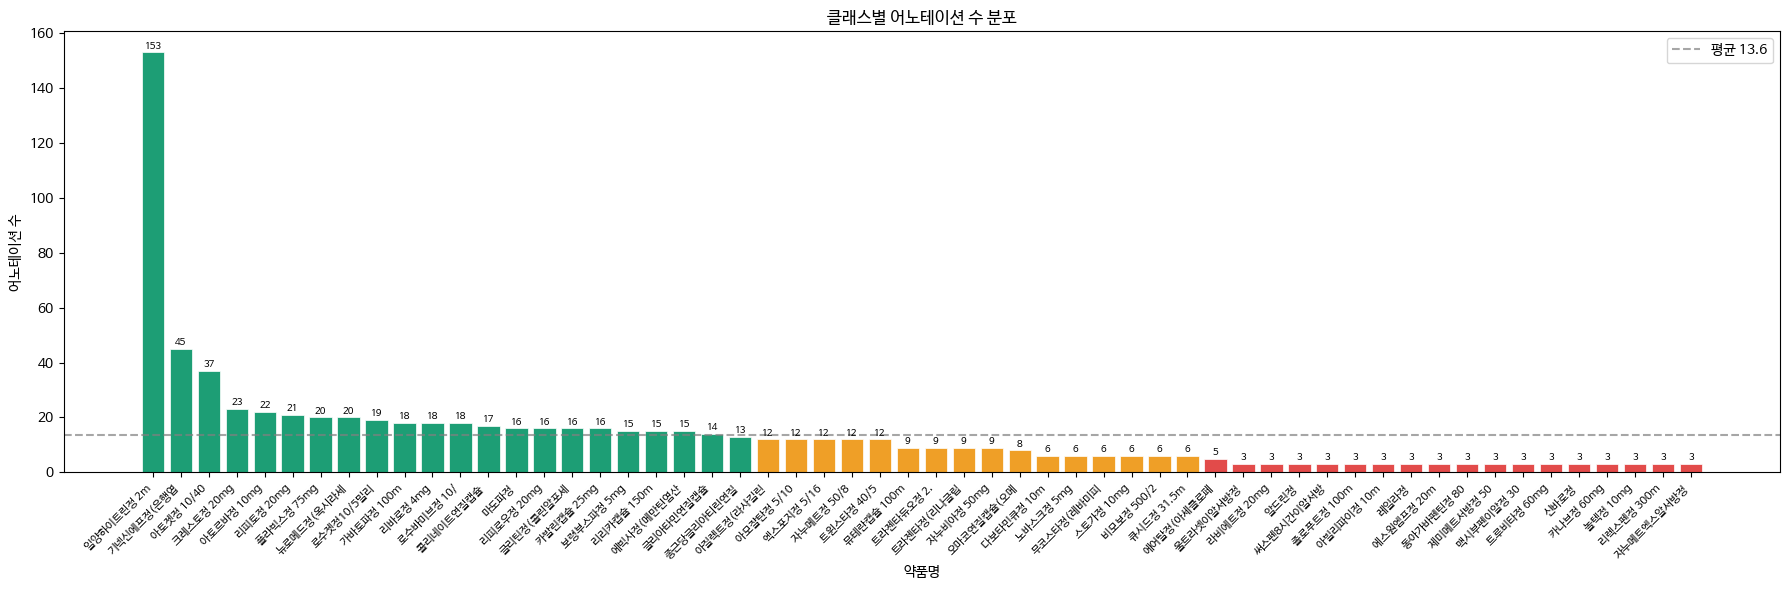

[2] 이미지당 알약 수


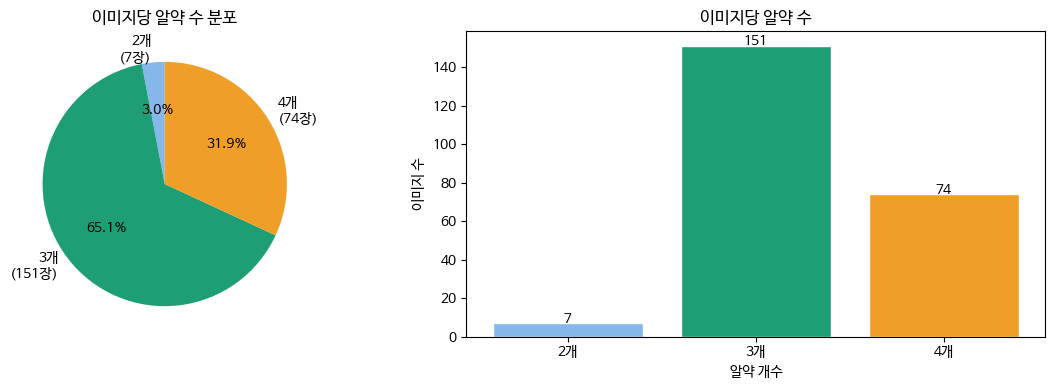

[3] bbox 크기 분포


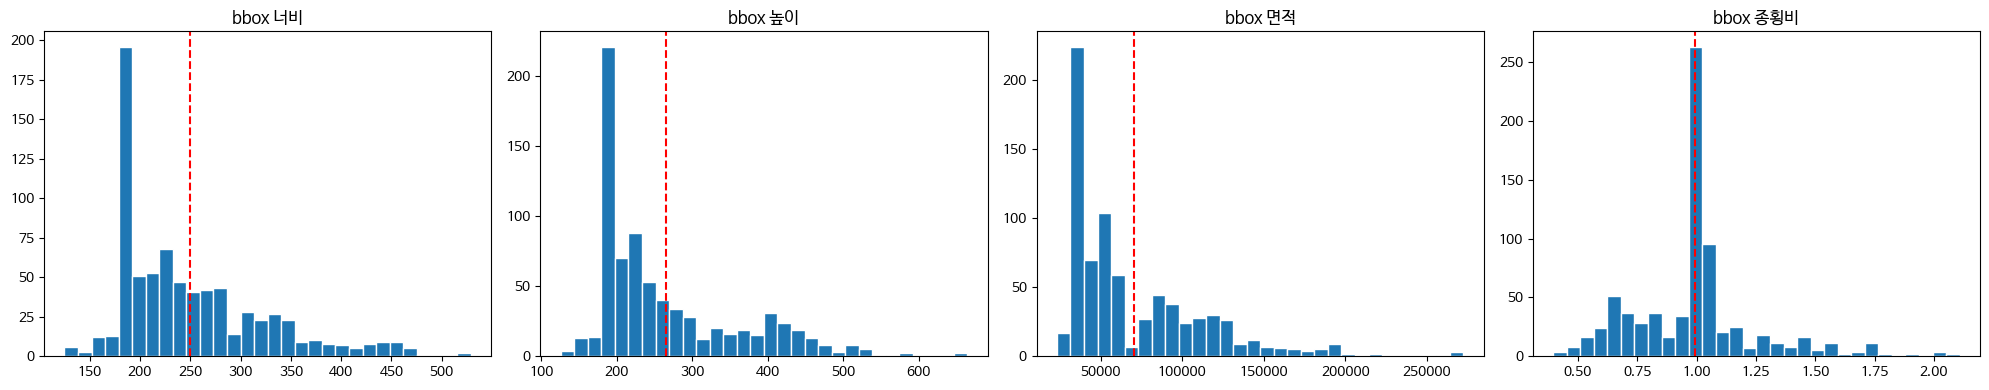

[4] bbox 위치 히트맵


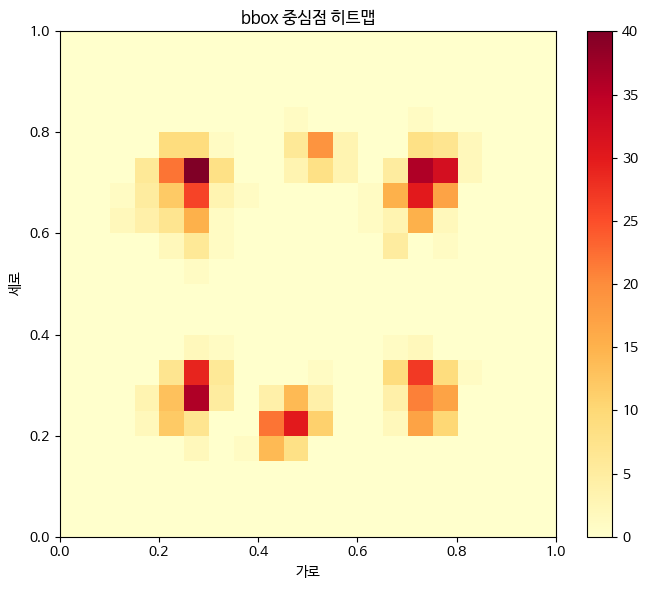

[5] 샘플 이미지 bbox


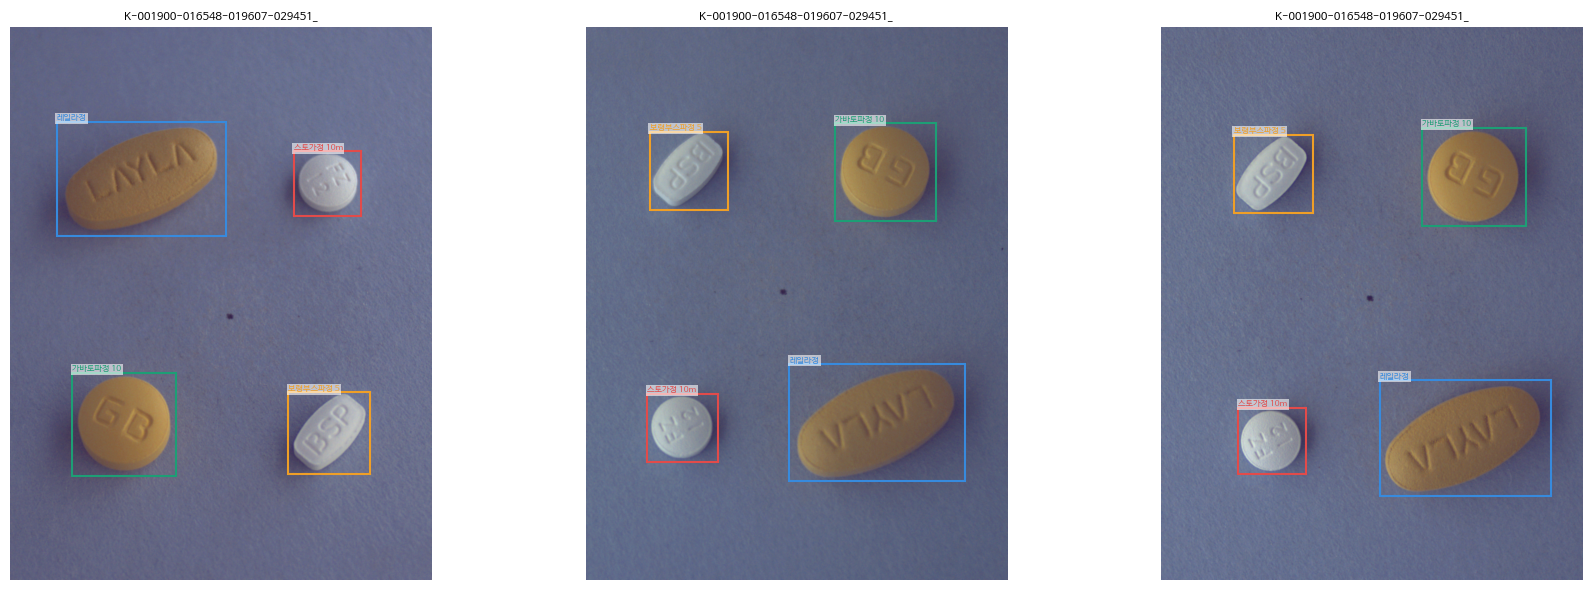


EDA 요약
이미지 크기 범위 : 976~976 x 1280~1280
bbox 평균 너비 : 250.0
bbox 평균 높이 : 265.8
클래스 불균형 : 153 / 3 = 51.0배
저장 위치 : eda_output


In [10]:
result = run_eda_from_coco(
    coco_json_path=train_coco_path,
    train_images_path=train_images_path,
    dlid_to_name=dlid_to_name,
    output_dir=OUTPUT_DIR
)

### 알약 속성 분석 (색상, 모양, 방향 등)

In [11]:
import numpy as np
import pandas as pd

def analyze_pill_attributes(annotation_metadata_objects, output_dir=OUTPUT_DIR, show_plot=True, save_prefix='eda', sections=None):
    df_meta = pd.DataFrame(annotation_metadata_objects)

    if sections is None:
        sections = ('attributes', 'size', 'drug_class')
    sections = tuple(sections)

    required_columns_by_section = {
        'attributes': ['color_class1', 'drug_shape', 'form_code_name', 'drug_dir'],
        'size': ['thick', 'leng_long', 'leng_short'],
        'drug_class': ['di_etc_otc_code', 'di_class_no'],
    }

    invalid_sections = [section for section in sections if section not in required_columns_by_section]
    if invalid_sections:
        raise ValueError(f'지원하지 않는 section이 있습니다: {invalid_sections}')

    required_columns = []
    for section in sections:
        required_columns.extend(required_columns_by_section[section])
    missing_columns = [col for col in dict.fromkeys(required_columns) if col not in df_meta.columns]
    if missing_columns:
        raise ValueError(f'필수 컬럼이 없습니다: {missing_columns}')

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    palette = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#76B7B2', '#EDC948', '#B07AA1']
    color_map = {
        '하양': '#EEEEEE', '주황': '#FF8C00', '분홍': '#FFB6C1', '노랑': '#FFD700',
        '갈색': '#8B4513', '초록': '#3CB371', '파랑': '#4169E1', '보라': '#9370DB',
        '빨강': '#DC143C', '회색': '#A9A9A9', '검정': '#2F4F4F', '연두': '#90EE90'
    }

    results = {
        'df_meta': df_meta,
        'sections': sections,
    }

    def plot_bar(ax, series, title, color_list=None, top_n=None, ylabel='어노테이션 수'):
        vc = series.value_counts().dropna()
        if top_n:
            vc = vc.head(top_n)
        colors = color_list if color_list else palette[:len(vc)]
        bars = ax.bar(vc.index.astype(str), vc.values, color=colors[:len(vc)], edgecolor='white', linewidth=1.2)
        for bar, v in zip(bars, vc.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{v}\n({v / vc.sum() * 100:.1f}%)', ha='center', va='bottom', fontsize=9)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_ylabel(ylabel)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
        return vc

    if 'attributes' in sections:
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        color1_vc = df_meta['color_class1'].value_counts().dropna().head(12)
        bar_colors = [color_map.get(c, '#AAAAAA') for c in color1_vc.index]
        bars = axes[0,0].bar(color1_vc.index.astype(str), color1_vc.values, color=bar_colors, edgecolor='gray', linewidth=1)
        for bar, v in zip(bars, color1_vc.values):
            axes[0,0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(v), ha='center', va='bottom', fontsize=10)
        axes[0,0].set_title('알약 색상(color_class1) 분포', fontsize=14, fontweight='bold')
        axes[0,0].set_ylabel('어노테이션 수')
        plt.setp(axes[0,0].get_xticklabels(), rotation=30, ha='right')

        shape_vc = plot_bar(axes[0,1], df_meta['drug_shape'], '알약 모양(drug_shape) 분포', color_list=list(palette))
        form_vc = plot_bar(axes[1,0], df_meta['form_code_name'], '제형 분류(form_code_name) 분포', color_list=list(palette))

        dir_vc = df_meta['drug_dir'].value_counts().dropna()
        axes[1,1].pie(dir_vc.values, labels=dir_vc.index, autopct='%1.1f%%', colors=[palette[4], palette[5]], startangle=90, textprops={'fontsize': 13})
        axes[1,1].set_title('알약 방향(drug_dir) 분포', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.savefig(output_dir / f'{save_prefix}_pill_attrs.png', dpi=150, bbox_inches='tight')
        if show_plot:
            plt.show()
        plt.close()

        results['color_class1_counts'] = color1_vc.to_dict()
        results['drug_shape_counts'] = shape_vc.to_dict()
        results['form_code_name_counts'] = form_vc.to_dict()
        results['drug_dir_counts'] = dir_vc.to_dict()

    if 'size' in sections:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for ax, col, label, color in zip(
            axes,
            ['thick', 'leng_long', 'leng_short'],
            ['두께 (mm)', '장축 (mm)', '단축 (mm)'],
            palette[:3]
        ):
            vals = pd.to_numeric(df_meta[col], errors='coerce').dropna()
            ax.hist(vals, bins=25, color=color, edgecolor='white', linewidth=1)
            ax.axvline(vals.mean(), color='red', linestyle='--', label=f'평균 {vals.mean():.1f}')
            ax.set_title(f'알약 {label} 분포', fontsize=14, fontweight='bold')
            ax.set_xlabel(label)
            ax.set_ylabel('빈도')
            ax.legend()

        plt.tight_layout()
        plt.savefig(output_dir / f'{save_prefix}_pill_size.png', dpi=150, bbox_inches='tight')
        if show_plot:
            plt.show()
        plt.close()

        results['thick_mean'] = pd.to_numeric(df_meta['thick'], errors='coerce').dropna().mean()
        results['leng_long_mean'] = pd.to_numeric(df_meta['leng_long'], errors='coerce').dropna().mean()
        results['leng_short_mean'] = pd.to_numeric(df_meta['leng_short'], errors='coerce').dropna().mean()

    if 'drug_class' in sections:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        etc_vc = df_meta['di_etc_otc_code'].value_counts().dropna()
        axes[0].pie(etc_vc.values, labels=etc_vc.index, autopct='%1.1f%%', colors=[palette[0], palette[1]], startangle=90, textprops={'fontsize': 13})
        axes[0].set_title('전문/일반 의약품 비율', fontsize=14, fontweight='bold')

        class_vc = df_meta['di_class_no'].value_counts().head(15)
        axes[1].barh(class_vc.index.astype(str)[::-1], class_vc.values[::-1], color=palette[2])
        axes[1].set_title('약품 분류(di_class_no) 상위 15', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('어노테이션 수')
        for i, v in enumerate(class_vc.values[::-1]):
            axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig(output_dir / f'{save_prefix}_drug_class.png', dpi=150, bbox_inches='tight')
        if show_plot:
            plt.show()
        plt.close()

        results['di_etc_otc_code_counts'] = etc_vc.to_dict()
        results['di_class_no_counts'] = class_vc.to_dict()

    return results


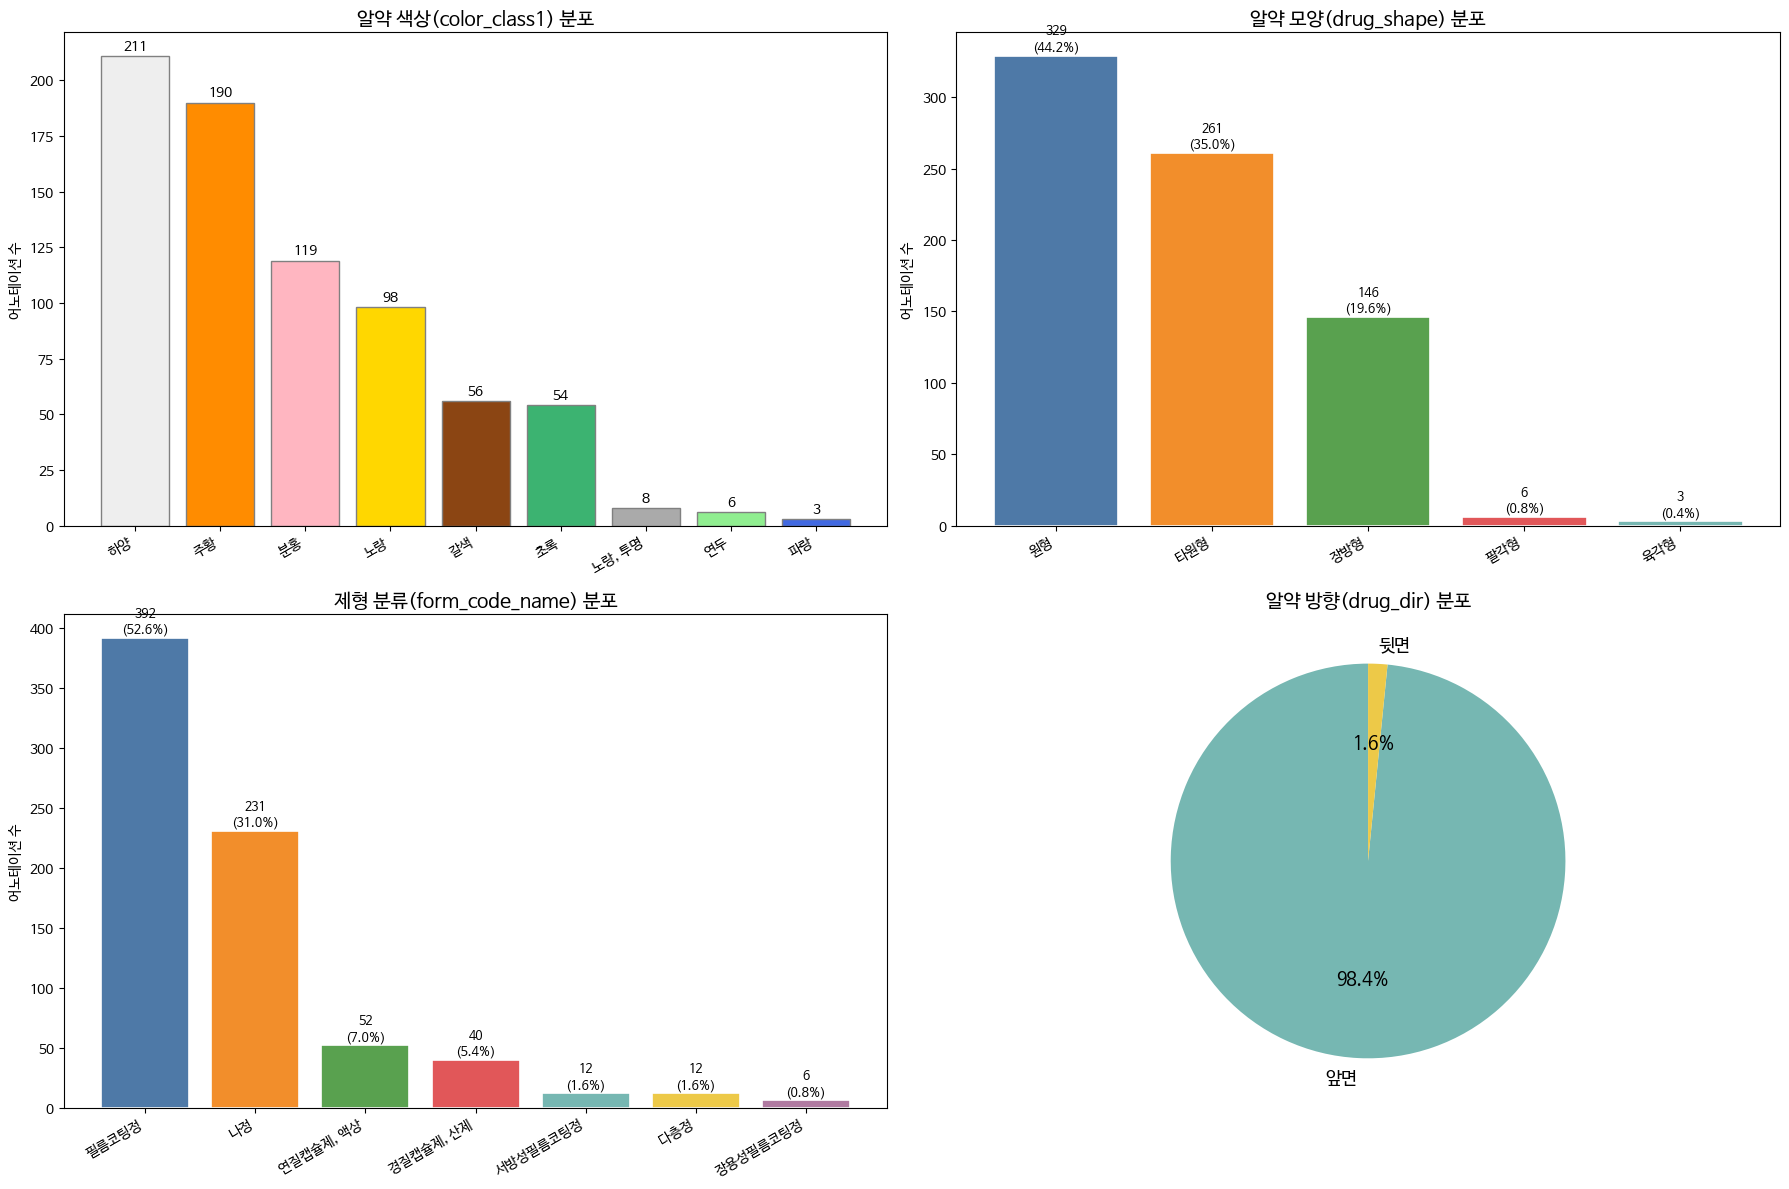

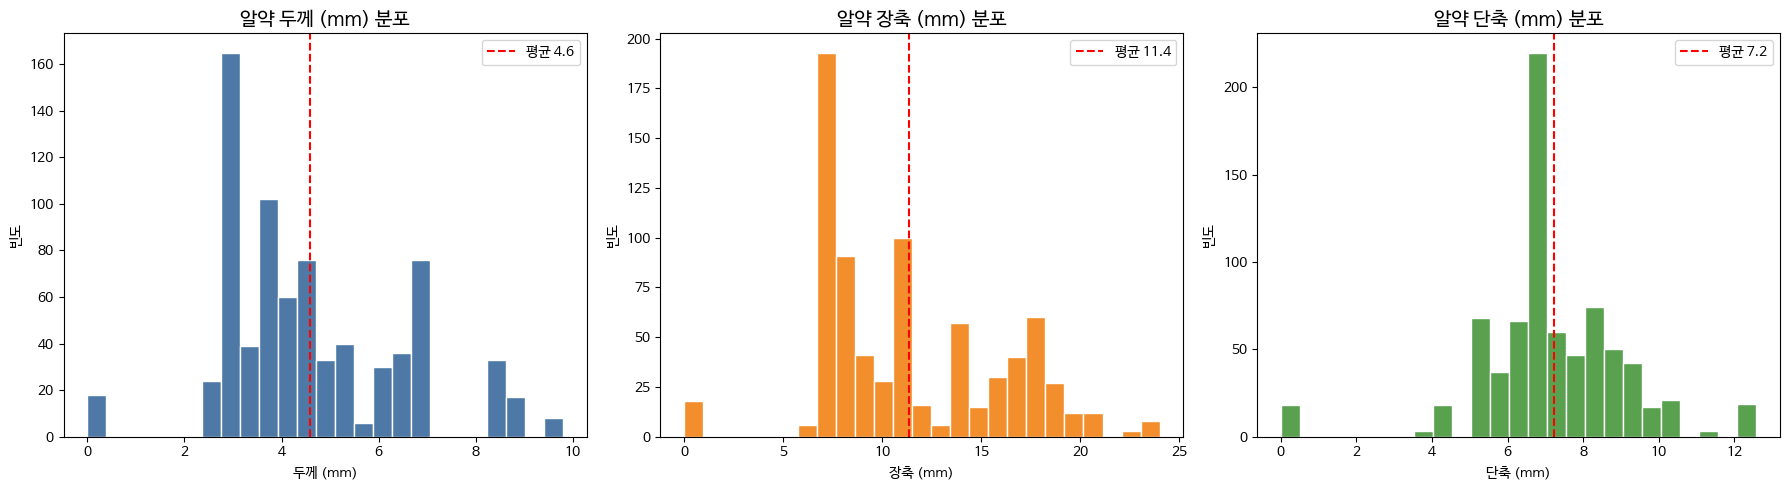

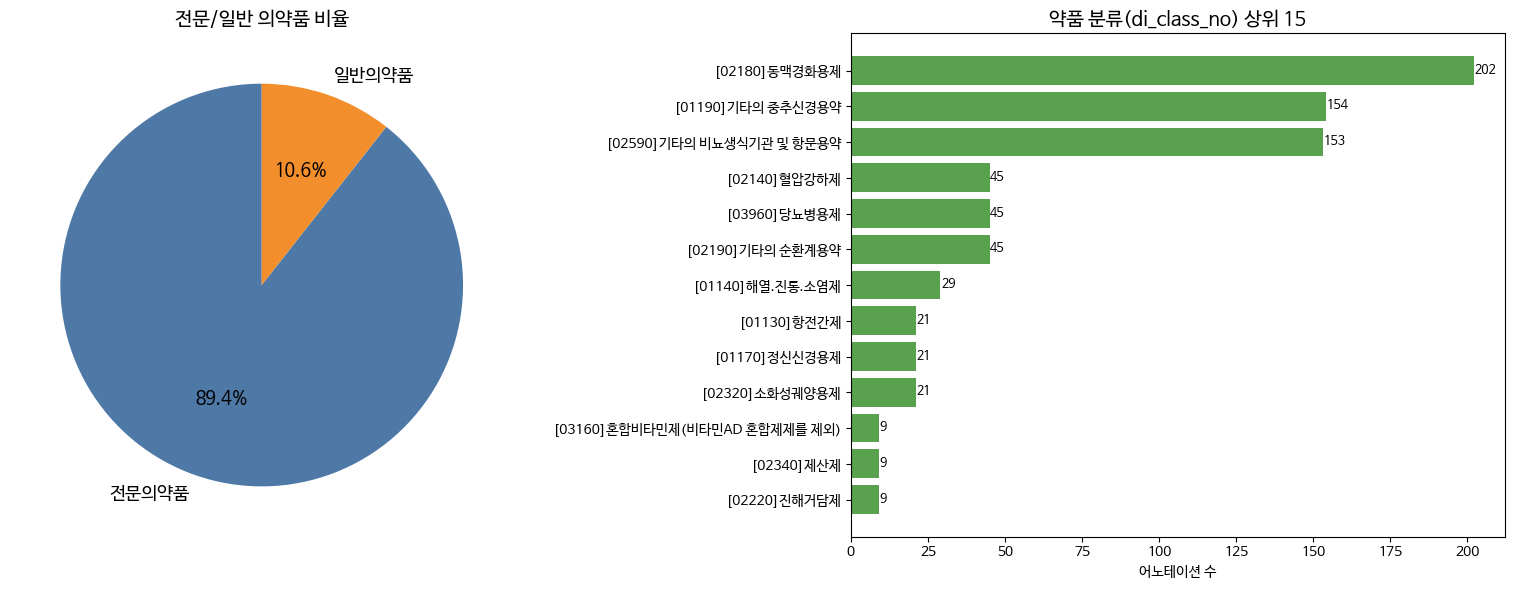

In [12]:
_ = analyze_pill_attributes(annotation_metadata)

### bbox 이상치 확인

In [13]:
import json

def check_bbox_outliers_from_coco(coco_json_path):
    outliers = []

    print(f"🔍 COCO JSON BBox 이상치 탐색 시작: {coco_json_path}")
    print("-" * 60)

    with open(coco_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    images = coco.get("images", [])
    annotations = coco.get("annotations", [])

    image_info_map = {
        img["id"]: {
            "file_name": img.get("file_name", ""),
            "width": img.get("width", 0),
            "height": img.get("height", 0),
        }
        for img in images
    }

    for ann in annotations:
        idx = ann.get("id")
        bbox = ann.get("bbox", [])

        if not isinstance(bbox, list) or len(bbox) != 4:
            print(f"🚨 [이상치 발견] annotation index: {idx} | 사유: bbox 형식 오류 | bbox: {bbox}")
            outliers.append({
                "annotation_index": idx,
                "image_id": ann.get("image_id"),
                "category_id": ann.get("category_id"),
                "bbox": bbox,
                "reason": ["bbox 형식 오류"],
                "full_ann": ann,
            })
            continue

        image_id = ann.get("image_id")
        img_info = image_info_map.get(image_id)

        if img_info is None:
            print(f"🚨 [이상치 발견] annotation index: {idx} | 사유: image_id {image_id} 없음")
            outliers.append({
                "annotation_index": idx,
                "image_id": image_id,
                "category_id": ann.get("category_id"),
                "bbox": bbox,
                "reason": [f"image_id {image_id} 없음"],
                "full_ann": ann,
            })
            continue

        img_w = img_info["width"]
        img_h = img_info["height"]

        x, y, w, h = bbox

        reasons = []
        if x < 0 or y < 0:
            reasons.append(f"음수 좌표(x:{x}, y:{y})")
        if w <= 0 or h <= 0:
            reasons.append(f"크기 오류(w:{w}, h:{h})")
        if x + w > img_w:
            reasons.append(f"가로 범위 초과(x+w:{x+w} > {img_w})")
        if y + h > img_h:
            reasons.append(f"세로 범위 초과(y+h:{y+h} > {img_h})")

        if reasons:
            print(
                f"🚨 [이상치 발견] "
                f"annotation index: {idx} | "
                f"image_file: {img_info['file_name']} | "
                f"사유: {', '.join(reasons)}"
            )

            outliers.append({
                "annotation_index": idx,
                "image_id": image_id,
                "image_file": img_info["file_name"],
                "category_id": ann.get("category_id"),
                "bbox": bbox,
                "img_size": (img_w, img_h),
                "reason": reasons,
                "full_ann": ann,
            })

    if not outliers:
        print("✅ 모든 BBox가 정상 범위 내에 있습니다.")

    return outliers

In [14]:
outliers = check_bbox_outliers_from_coco(train_coco_path)
print("이상치:", outliers)

🔍 COCO JSON BBox 이상치 탐색 시작: ./eda_output/train_coco.json
------------------------------------------------------------
🚨 [이상치 발견] annotation index: 730 | image_file: K-003351-016262-018357_0_2_0_2_75_000_200.png | 사유: 가로 범위 초과(x+w:6878 > 976)
이상치: [{'annotation_index': 730, 'image_id': 72, 'image_file': 'K-003351-016262-018357_0_2_0_2_75_000_200.png', 'category_id': 18357, 'bbox': [6567, 625, 311, 315], 'img_size': (976, 1280), 'reason': ['가로 범위 초과(x+w:6878 > 976)'], 'full_ann': {'id': 730, 'image_id': 72, 'category_id': 18357, 'bbox': [6567, 625, 311, 315], 'area': 97965, 'iscrowd': 0, 'segmentation': [], 'ignore': 0}}]


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pycocotools.coco import COCO
import os
import json

def show_annotation_image(annotation_ids, json_path, base_img_path):
    coco = COCO(json_path)   # 여기서 json 파일 경로 받음

    for ann_id in annotation_ids:
        ann = coco.loadAnns([ann_id])[0]
        img_info = coco.loadImgs([ann["image_id"]])[0]

        target_file = img_info["file_name"]
        bbox = ann["bbox"]
        img_w = img_info["width"]
        img_h = img_info["height"]

        # 이미지 찾기
        img_full_path = None
        for root, dirs, files in os.walk(base_img_path):
            if target_file in files:
                img_full_path = os.path.join(root, target_file)
                break

        if img_full_path:
            img = Image.open(img_full_path)

            fig, ax = plt.subplots(figsize=(10, 8))
            ax.imshow(img)

            rect = patches.Rectangle(
                (bbox[0], bbox[1]),
                bbox[2],
                bbox[3],
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)

            ax.set_xlim(0, max(img_w, bbox[0] + bbox[2] + 100))
            ax.set_ylim(max(img_h, bbox[1] + bbox[3] + 100), 0)

            plt.title(f"{target_file} | Annotation ID: {ann_id}")
            plt.show()

        print("\n📄 [Raw Annotation Data]")
        print("-" * 60)
        print(json.dumps(ann, indent=4, ensure_ascii=False))
        print("-" * 60)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


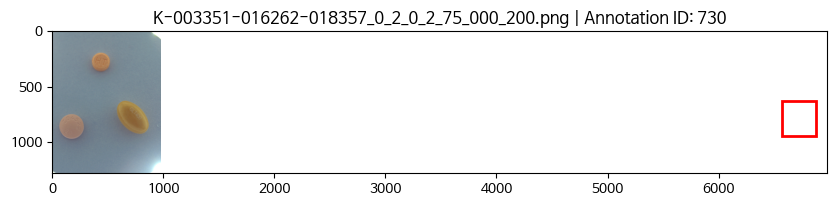


📄 [Raw Annotation Data]
------------------------------------------------------------
{
    "id": 730,
    "image_id": 72,
    "category_id": 18357,
    "bbox": [
        6567,
        625,
        311,
        315
    ],
    "area": 97965,
    "iscrowd": 0,
    "segmentation": [],
    "ignore": 0
}
------------------------------------------------------------


In [16]:
ids = [item["annotation_index"] for item in outliers]

show_annotation_image(
    ids,
    train_coco_path,
    train_images_path
)

18357: 종근당글리아티린연질캡슐(콜린알포세레이트) 약제의 bbox x 좌표 6567 => 567 로 수정 필요

### 이상치 수정

In [17]:
import json
import shutil
from pathlib import Path

def update_coco_annotation_bbox(coco_json_path, annotation_id, new_bbox, save_path=None, make_backup=True):
    """
    COCO JSON에서 특정 annotation id의 bbox를 수정한다.

    Parameters
    ----------
    coco_json_path : str
        원본 COCO JSON 경로
    annotation_id : int
        수정할 annotation의 id
    new_bbox : list | tuple
        새 bbox [x, y, w, h]
    save_path : str | None
        저장 경로. None이면 원본 파일 덮어씀
    make_backup : bool
        원본 덮어쓸 때 백업 생성 여부

    Returns
    -------
    dict
        수정된 annotation 객체
    """

    if not isinstance(new_bbox, (list, tuple)) or len(new_bbox) != 4:
        raise ValueError("new_bbox는 [x, y, w, h] 형태여야 합니다.")

    x, y, w, h = [float(v) for v in new_bbox]
    if w <= 0 or h <= 0:
        raise ValueError("bbox의 width와 height는 0보다 커야 합니다.")

    coco_json_path = Path(coco_json_path)
    output_path = Path(save_path) if save_path is not None else coco_json_path

    with open(coco_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    annotations = coco.get("annotations", [])
    target_ann = None

    for ann in annotations:
        if ann.get("id") == annotation_id:
            ann["bbox"] = [x, y, w, h]
            ann["area"] = w * h
            target_ann = ann
            break

    if target_ann is None:
        raise ValueError(f"annotation id {annotation_id} 를 찾지 못했습니다.")

    if save_path is None and make_backup:
        backup_path = coco_json_path.with_suffix(coco_json_path.suffix + ".bak")
        shutil.copy2(coco_json_path, backup_path)
        print(f"백업 파일 생성: {backup_path}")

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(coco, f, ensure_ascii=False, indent=2)

    print(f"수정 완료: annotation_id={annotation_id}, bbox={[x, y, w, h]}")
    print(f"저장 위치: {output_path}")

    return target_ann

In [18]:
update_coco_annotation_bbox(
    train_coco_path,
    annotation_id=730,
    new_bbox=[567.0,
        625.0,
        311.0,
        315.0]
)

백업 파일 생성: eda_output/train_coco.json.bak
수정 완료: annotation_id=730, bbox=[567.0, 625.0, 311.0, 315.0]
저장 위치: eda_output/train_coco.json


{'id': 730,
 'image_id': 72,
 'category_id': 18357,
 'bbox': [567.0, 625.0, 311.0, 315.0],
 'area': 97965.0,
 'iscrowd': 0,
 'segmentation': [],
 'ignore': 0}

In [19]:
outliers = check_bbox_outliers_from_coco(train_coco_path)
print("이상치:", outliers)

🔍 COCO JSON BBox 이상치 탐색 시작: ./eda_output/train_coco.json
------------------------------------------------------------
✅ 모든 BBox가 정상 범위 내에 있습니다.
이상치: []


loading annotations into memory...
Done (t=0.12s)
creating index...
index created!


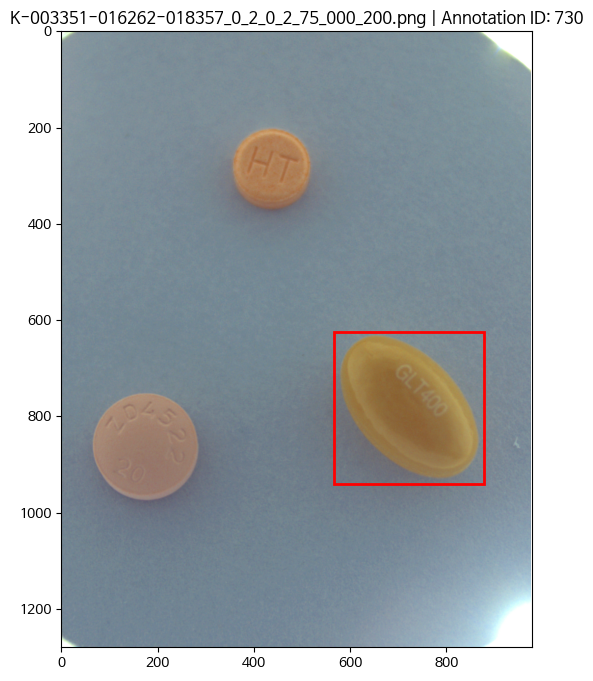


📄 [Raw Annotation Data]
------------------------------------------------------------
{
    "id": 730,
    "image_id": 72,
    "category_id": 18357,
    "bbox": [
        567.0,
        625.0,
        311.0,
        315.0
    ],
    "area": 97965.0,
    "iscrowd": 0,
    "segmentation": [],
    "ignore": 0
}
------------------------------------------------------------


In [20]:
show_annotation_image(
    [730],
    train_coco_path,
    train_images_path
)

## 데이터 품질 검사

> 통합 COCO JSON(`train_coco.json`) 기준으로 7가지 항목을 자동 검사합니다.  
> 헬스케어 도메인에서 어노테이션 오류는 **의료 안전에 직결**되므로 필수 수행 단계입니다.
>
> | 항목 | 검사 내용 | 수준 |
> |---|---|---|
> | 1 | 이미지 파일 누락 (PNG 미존재) | 🚨 즉시 조치 |
> | 2 | 어노테이션 없는 이미지 (n_pills = 0) | ⚠️ 확인 권장 |
> | 3 | iscrowd = 1 어노테이션 | ⚠️ 확인 권장 |
> | 4 | 좌표 이상 BBox (음수·이미지 범위 초과) | 🚨 즉시 조치 |
> | 5 | 극소 BBox (w 또는 h < 10px) | ⚠️ 확인 권장 |
> | 6 | 중복 어노테이션 | ⚠️ 확인 권장 |
> | 7 | 유효하지 않은 category_id | 🚨 즉시 조치 |  

In [ ]:
import os
from collections import defaultdict
import json

# ──────────────────────────────────────────────────────────────────
# 데이터 품질 검사
# 입력: 통합된 coco json 파일 위치 (셀[10] 생성)
#       train_images_path
# ──────────────────────────────────────────────────────────────────
def check_coco_data_quality(coco_json_path, train_images_path):
    print('=' * 60)
    print('🔍 데이터 품질 검사 결과')
    print('=' * 60)

    with open(coco_json_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    coco_annotations = coco["annotations"]
    coco_images = coco["images"]
    coco_categories = coco["categories"]


    issues = []   # 즉시 조치 필요 항목 수집

    # ── 사전 준비: 검사에 필요한 인덱스 구조 생성 ─────────────────────

    # image_id → 이미지 메타 정보 (width, height, file_name)
    image_meta_map = {img['id']: img for img in coco_images}

    # image_id → 해당 이미지의 어노테이션 수 집계
    ann_count_per_image = defaultdict(int)
    for ann in coco_annotations:
        ann_count_per_image[ann['image_id']] += 1

    # 유효한 category_id 집합
    valid_category_ids = {cat['id'] for cat in coco_categories}

    # train_images/ 폴더 내 실제 존재하는 PNG 파일명 집합
    existing_pngs = set(os.listdir(train_images_path))


    # ── [1] 이미지 파일 누락 ──────────────────────────────────────────
    # coco_images 에 등록된 file_name 이 train_images/ 에 실제로 있는지 확인
    missing_files = [
        img for img in coco_images
        if img['file_name'] not in existing_pngs
    ]
    print(f'\n[1] 이미지 파일 누락: {len(missing_files)}개')
    if missing_files:
        issues.append(f'파일 누락 {len(missing_files)}개')
        sample = [img['file_name'] for img in missing_files[:5]]
        print(f'    → 누락 파일 (최대 5개): {sample}')


    # ── [2] 어노테이션 없는 이미지 ───────────────────────────────────
    # coco_images 에 등록되었지만 어노테이션이 0개인 이미지
    no_ann_images = [
        img for img in coco_images
        if ann_count_per_image[img['id']] == 0
    ]
    print(f'\n[2] 어노테이션 없는 이미지 (n_pills=0): {len(no_ann_images)}개')
    if no_ann_images:
        issues.append(f'어노테이션 누락 이미지 {len(no_ann_images)}개')
        print('    → 학습 제외 또는 background 클래스 활용 고려')


    if coco_annotations:

        # ── [3] iscrowd = 1 어노테이션 ───────────────────────────────
        # iscrowd=1 은 군중·밀집 객체로, 평가 지표(mAP) 계산에서 제외해야 함
        crowd_anns = [
            ann for ann in coco_annotations
            if ann.get('iscrowd', 0) == 1
        ]
        print(f'\n[3] iscrowd=1 어노테이션: {len(crowd_anns)}개')
        if crowd_anns:
            issues.append(f'iscrowd {len(crowd_anns)}개')
            print('    → 학습 전 제거 권장 (평가 지표 왜곡 가능)')


        # ── [4] 좌표 이상 BBox (음수 / 이미지 범위 초과) ─────────────
        # COCO bbox 형식: [x_min, y_min, width, height] (픽셀 절댓값)
        # 조건: x<0 또는 y<0 또는 w<=0 또는 h<=0
        #       또는 x+w > img_width 또는 y+h > img_height
        invalid_coord_anns = []
        for ann in coco_annotations:
            bbox = ann.get('bbox', [])
            if not isinstance(bbox, list) or len(bbox) != 4:
                invalid_coord_anns.append(ann)
                continue
            x, y, w, h = bbox
            img_meta = image_meta_map.get(ann['image_id'], {})
            img_w = img_meta.get('width', 0)
            img_h = img_meta.get('height', 0)
            if (x < 0 or y < 0 or w <= 0 or h <= 0
                    or (img_w > 0 and x + w > img_w)
                    or (img_h > 0 and y + h > img_h)):
                invalid_coord_anns.append(ann)

        print(f'\n[4] 좌표 이상 BBox (음수/범위 초과): {len(invalid_coord_anns)}개')
        if invalid_coord_anns:
            issues.append(f'좌표 이상 {len(invalid_coord_anns)}개')
            print('    → 상세 내역 (최대 5개):')
            for a in invalid_coord_anns[:5]:
                img_meta = image_meta_map.get(a['image_id'], {})
                print(f'      annotation_id={a["id"]}  '
                      f'image_id={a["image_id"]}  '
                      f'bbox={a.get("bbox")}  '
                      f'img_size=({img_meta.get("width")},{img_meta.get("height")})')


        # ── [5] 극소 BBox (w 또는 h < 10px) ─────────────────────────
        # 10px 이하 BBox는 레이블 오류이거나 검출 의미가 없는 노이즈일 가능성 높음
        tiny_anns = [
            ann for ann in coco_annotations
            if isinstance(ann.get('bbox'), list)
            and len(ann['bbox']) == 4
            and (ann['bbox'][2] < 10 or ann['bbox'][3] < 10)
        ]
        print(f'\n[5] 극소 BBox (w 또는 h < 10px): {len(tiny_anns)}개')
        if tiny_anns:
            issues.append(f'극소 BBox {len(tiny_anns)}개')
            print('    → 레이블 오류 가능성 높음, 육안 확인 권장')
            for a in tiny_anns[:3]:
                print(f'      annotation_id={a["id"]}  bbox={a["bbox"]}')


        # ── [6] 중복 어노테이션 ───────────────────────────────────────
        # 동일 이미지 내 (image_id, category_id, bbox) 가 완전히 같은 어노테이션
        seen_ann_keys = set()
        duplicate_anns = []
        for ann in coco_annotations:
            bbox = ann.get('bbox', [])
            key  = (
                ann['image_id'],
                ann.get('category_id'),
                tuple(bbox) if isinstance(bbox, list) else bbox
            )
            if key in seen_ann_keys:
                duplicate_anns.append(ann)
            else:
                seen_ann_keys.add(key)

        print(f'\n[6] 중복 어노테이션: {len(duplicate_anns)}개')
        if duplicate_anns:
            issues.append(f'중복 어노테이션 {len(duplicate_anns)}개')
            print('    → 제거 시 coco_annotations에서 drop_duplicates 처리 필요')


        # ── [7] 유효하지 않은 category_id ────────────────────────────
        # coco_categories 에 등록되지 않은 category_id를 가진 어노테이션
        invalid_cat_anns = [
            ann for ann in coco_annotations
            if ann.get('category_id') not in valid_category_ids
        ]
        print(f'\n[7] 유효하지 않은 category_id: {len(invalid_cat_anns)}개')
        if invalid_cat_anns:
            issues.append(f'유효하지 않은 클래스 {len(invalid_cat_anns)}개')
            invalid_ids = {a.get('category_id') for a in invalid_cat_anns}
            print(f'    → 발견된 미등록 category_id: {sorted(invalid_ids)}')


    # ── 최종 요약 ─────────────────────────────────────────────────────
    print('\n' + '=' * 60)
    if issues:
        print(f'⚠️  발견된 이슈 ({len(issues)}건): {", ".join(issues)}')
        print('→ 학습 전 데이터 클렌징 필요')
    else:
        print('✅ 주요 품질 이슈 없음 — 데이터 품질 양호')
    print('=' * 60)


In [29]:
check_coco_data_quality(train_coco_path, train_images_path)

🔍 데이터 품질 검사 결과

[1] 이미지 파일 누락: 0개

[2] 어노테이션 없는 이미지 (n_pills=0): 0개

[3] iscrowd=1 어노테이션: 0개

[4] 좌표 이상 BBox (음수/범위 초과): 0개

[5] 극소 BBox (w 또는 h < 10px): 0개

[6] 중복 어노테이션: 0개

[7] 유효하지 않은 category_id: 0개

✅ 주요 품질 이슈 없음 — 데이터 품질 양호


## 분석 결과 요약


| 분석 항목 | 세부항목 | 분석 결과 |
| :--- | :--- | :---|
| **파일명 규칙** | |`K-`로 시작하는 알약 ID들이 하이픈(`-`)으로 연결된 구조 (예: `K-001900-016548-...`) |
| **파일 기술 통계** | 이미지 개수| 총 232개 파일, 총 용량 `387.67 MB` |
|| 확장자| `.png`|
|| 해상도| `976 x 1280`|
| **이미지 특성** | 어노테이션 개수 | `763개`|
|| 배경| 모두 연회색|
|| 조명| 모두 주백색|
|| 촬영방향| 앞면 `751장` / 뒷면 `12장`|
| **바운딩 박스** | 크기 범위|W `125-529` / H `126-664`|
||평균 크기| W `250.0`, H `265.8` |
||종횡비| 거의 `1:1` (원형·타원 위주)|
| **알약 속성** | 주요 색상 |하양·주황·분홍·노랑|
||주요 모양| 원형`329` / 타원형`261` / 장방형`146`|
| **클래스 불균형** | |최대 빈도 클래스(153개) vs 최소 빈도 클래스(3개), 불균형 비율: **51.0배** |
| **데이터 이상치** | |가로 범위 초과 사례 확인 (`x+w: 6878.0` > `img_w: 976`). 해당 건은 수정 가능. |
| **객체 밀도 분포** | |이미지당 알약 수: **3개(151장)**, **4개(74장)**, **2개(7장)** 순으로 구성됨. |
| **학습 시 주의사항** | |Rotate 증강 적용 확인. 데이터 누수(Leakage) 방지를 위한 **그룹별 Split** 필요. |
| | | 클래스 불균형 → Focal Loss / Class Weighting 고려, bbox 별 알약 크롭 후 자체 이미지 생성 고려|
|||한 이미지에 최대 4개 객체 → Multi-object detection 필수|
|||배경·조명 고정 → 색상 지터링 증강으로 일반화 향상 필요|

